# Rossmann Store Sales — Machine Learning Models

Bohdan Pavlyshenko (https://www.linkedin.com/in/bpavlyshenko) 

**Dataset:** [Kaggle — Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales)

---

## Overview

We compare **Random Forest**, **XGBoost**, **LightGBM**, and
**Neural Network** regressors, and combine their predictions using a **stacking ensemble**.

**Learning objectives:**
- Explore the dataset with EDA before modelling
- Train ensemble and neural network models for time-series forecasting
- Apply a temporal hold-out strategy for realistic evaluation
- Compare models with a stacking meta-learner


In [28]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import keras
from keras.layers import Dense, Dropout, Input
from keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
print("Libraries loaded. Keras backend:", keras.backend.backend())


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Libraries loaded. Keras backend: tensorflow


## 1. Helper Functions


In [29]:
def evaluate(y_true, y_pred, label=""):
    """Compute MAE, RMSE, and R² and optionally print them.

    Args:
        y_true (array-like): Ground-truth values.
        y_pred (array-like): Predictions.
        label (str): Optional label for printed output. Defaults to "".

    Returns:
        dict: Keys 'mae', 'rmse', 'r2'.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"{label:30s} | MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}


def plot_store_forecast(train_df, test_df, store_id, pred_col, target="logSales"):
    """Plot training and test actual vs predicted for a single store.

    Args:
        train_df (pd.DataFrame): Training DataFrame with Date index or column.
        test_df (pd.DataFrame): Test DataFrame with Date index or column.
        store_id (int): Store identifier.
        pred_col (str): Name of the prediction column.
        target (str): Target column name. Defaults to "logSales".
    """
    tr = train_df[train_df.Store == store_id].set_index("Date").sort_index()
    te = test_df[test_df.Store == store_id].set_index("Date").sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    train_rmse = root_mean_squared_error(tr[target], tr[pred_col])
    test_rmse  = root_mean_squared_error(te[target], te[pred_col])

    axes[0].plot(tr.index, tr[target],   label="Actual",    linewidth=1.0)
    axes[0].plot(tr.index, tr[pred_col], label="Predicted", linewidth=0.8, linestyle="--")
    axes[0].set_title(f"Store {store_id} — Train (RMSE={train_rmse:.3f})")
    axes[0].legend(fontsize=8)

    axes[1].plot(te.index, te[target],   label="Actual",    linewidth=1.0)
    axes[1].plot(te.index, te[pred_col], label="Predicted", linewidth=0.8, linestyle="--")
    axes[1].set_title(f"Store {store_id} — Test  (RMSE={test_rmse:.3f})")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 2. Data Loading


In [30]:
train_df = pd.read_csv("data/rossm_train_df.csv")
test_df  = pd.read_csv("data/rossm_test_df.csv")

train_df["Date"] = pd.to_datetime(train_df["Date"])
test_df["Date"]  = pd.to_datetime(test_df["Date"])

print(f"Train: {train_df.shape}  {train_df.Date.min().date()} → {train_df.Date.max().date()}")
print(f"Test : {test_df.shape}   {test_df.Date.min().date()} → {test_df.Date.max().date()}")
print(f"Stores: {train_df.Store.nunique()}")


Train: (73000, 18)  2013-01-01 → 2014-12-31
Test : (21200, 18)   2015-01-01 → 2015-07-31
Stores: 100


In [31]:
train_df.head()


,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,weekday,monthday,month,year,logSales,monthSales,logMonthSales
0,11,2014-12-31,3838,543,1.0,0.0,0,1.0,a,c,960.0,2,31,12,2014,8.252967,203106.000000,12.221488
1,12,2014-12-31,4871,609,1.0,0.0,0,1.0,a,c,1070.0,2,31,12,2014,8.491260,191943.387097,12.164961
2,17,2014-12-31,2639,367,1.0,0.0,0,1.0,a,a,50.0,2,31,12,2014,7.878534,159822.193548,11.981823
3,25,2014-12-31,7771,925,1.0,0.0,0,1.0,c,a,430.0,2,31,12,2014,8.958283,270211.516129,12.506964
4,31,2014-12-31,3150,363,1.0,0.0,0,1.0,d,c,9800.0,2,31,12,2014,8.055475,148262.677419,11.906748


## 3. Exploratory Data Analysis

### 3.1 Target Variable and Sales Distribution


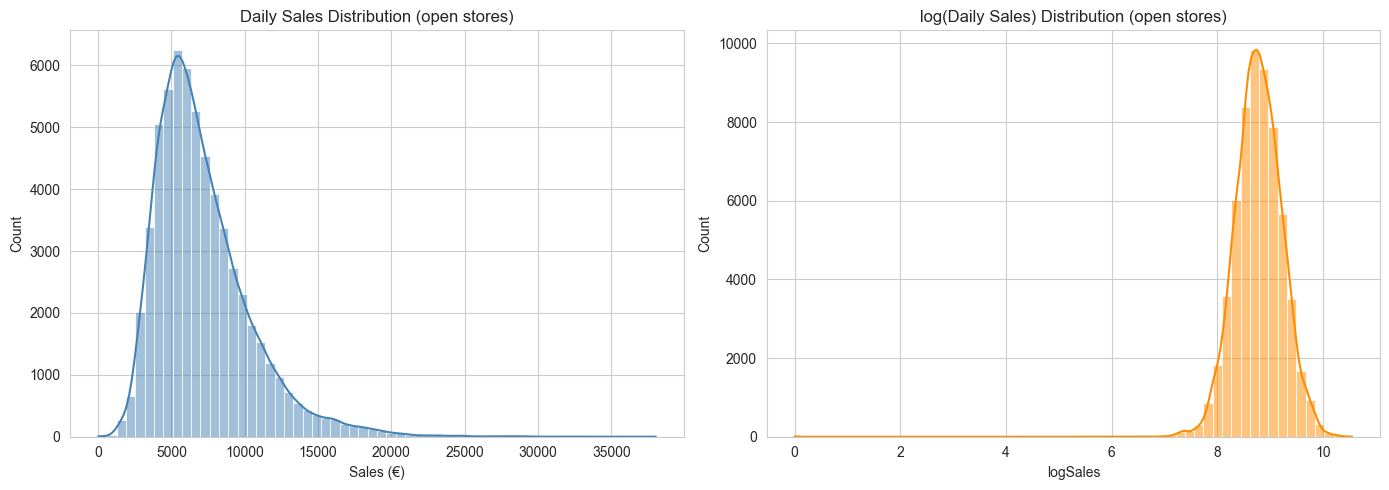

In [32]:
open_mask = train_df["Open"] == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df.loc[open_mask, "Sales"], bins=60, kde=True,
             ax=axes[0], color="steelblue")
axes[0].set_title("Daily Sales Distribution (open stores)")
axes[0].set_xlabel("Sales (€)")

sns.histplot(train_df.loc[open_mask, "logSales"], bins=60, kde=True,
             ax=axes[1], color="darkorange")
axes[1].set_title("log(Daily Sales) Distribution (open stores)")
axes[1].set_xlabel("logSales")

plt.tight_layout()
plt.show()


### 3.2 Sales by Store Type and Assortment


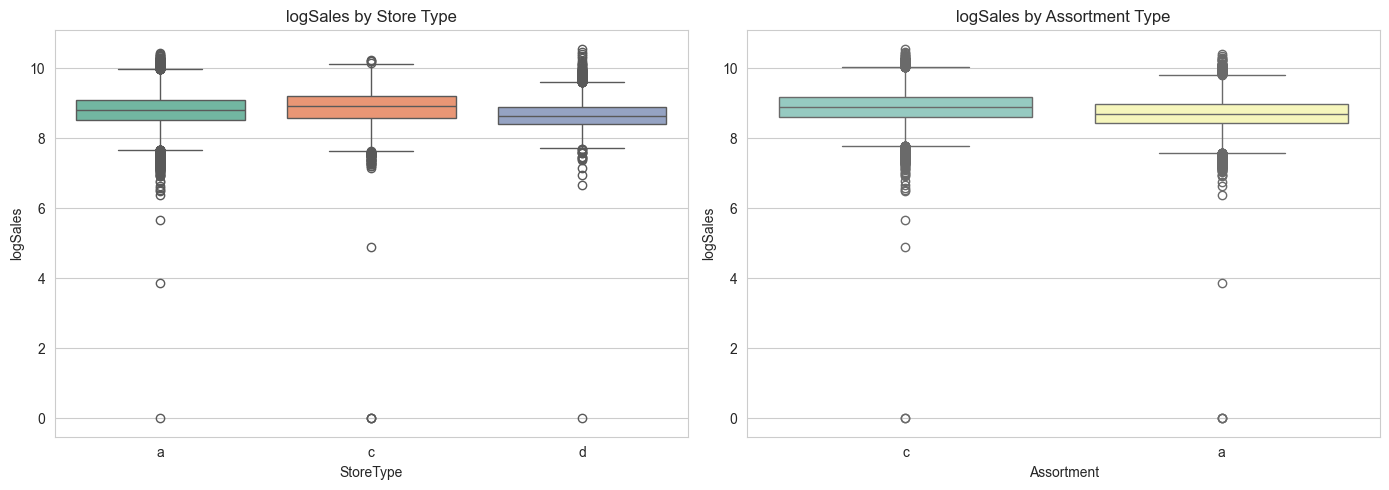

In [33]:
open_train = train_df[open_mask].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="StoreType", y="logSales", data=open_train, ax=axes[0], palette="Set2")
axes[0].set_title("logSales by Store Type")

sns.boxplot(x="Assortment", y="logSales", data=open_train, ax=axes[1], palette="Set3")
axes[1].set_title("logSales by Assortment Type")

plt.tight_layout()
plt.show()


### 3.3 Temporal Patterns


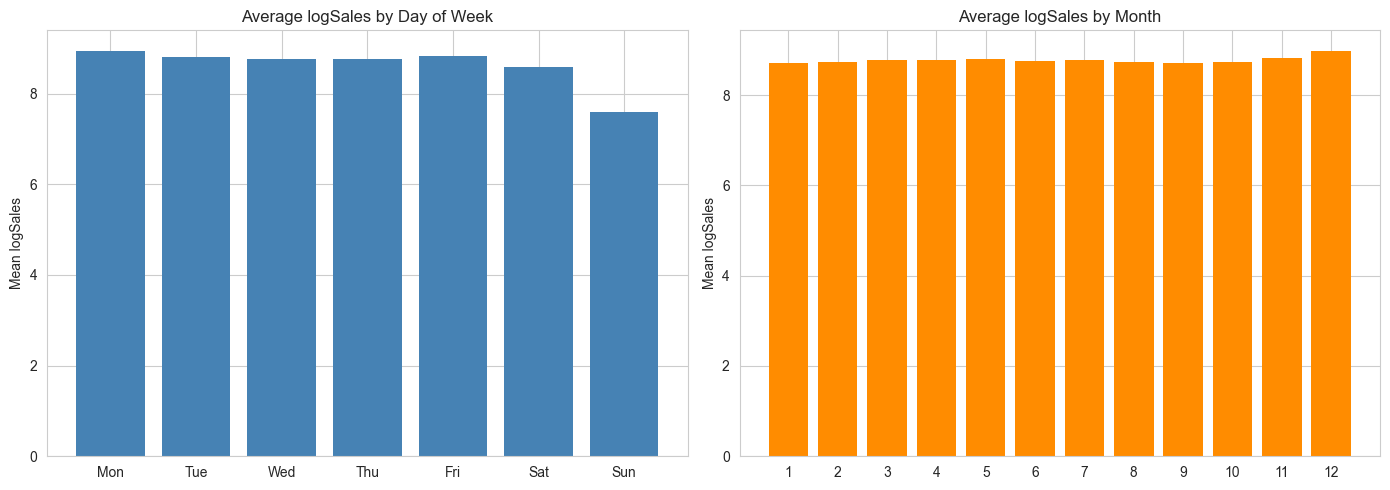

In [34]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow = open_train.groupby("weekday")["logSales"].mean()
axes[0].bar(dow.index, dow.values, color="steelblue", edgecolor="none")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].set_ylabel("Mean logSales")
axes[0].set_title("Average logSales by Day of Week")

month = open_train.groupby("month")["logSales"].mean()
axes[1].bar(month.index, month.values, color="darkorange", edgecolor="none")
axes[1].set_xticks(range(1, 13))
axes[1].set_ylabel("Mean logSales")
axes[1].set_title("Average logSales by Month")

plt.tight_layout()
plt.show()


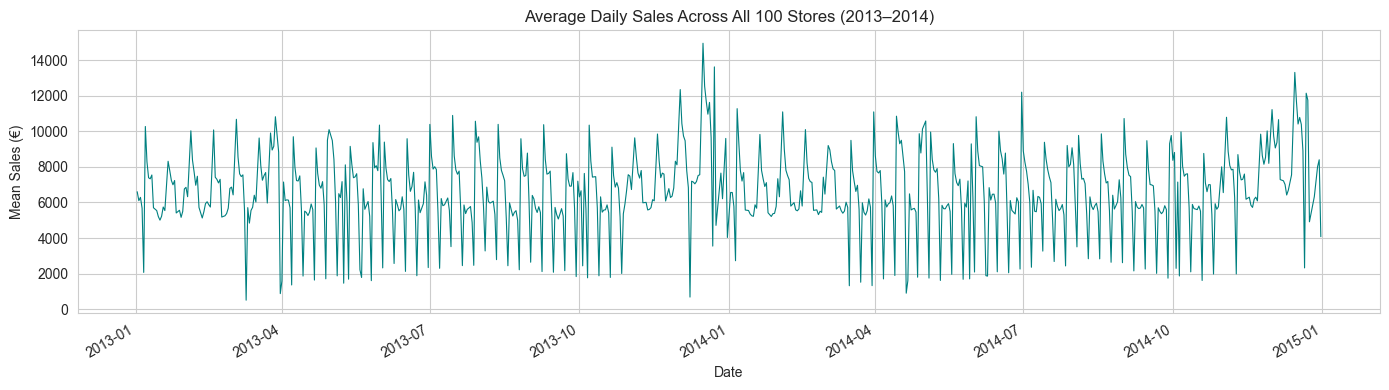

In [35]:
fig, ax = plt.subplots(figsize=(14, 4))
open_train.groupby("Date")["Sales"].mean().plot(ax=ax, linewidth=0.8, color="teal")
ax.set_title("Average Daily Sales Across All 100 Stores (2013–2014)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Sales (€)")
plt.tight_layout()
plt.show()


### 3.4 Competition Distance Distribution


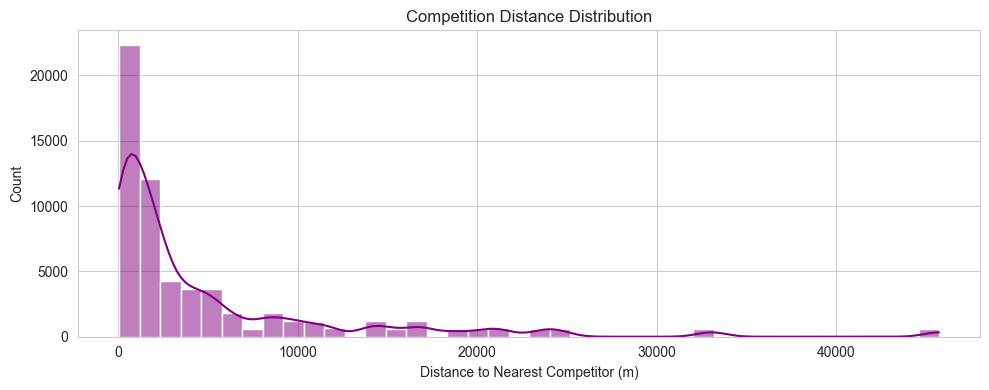

CompetitionDistance summary:
count    73000.000000
mean      4982.600000
std       7517.789931
min         50.000000
25%        525.000000
50%       2020.000000
75%       5365.000000
max      45740.000000
Name: CompetitionDistance, dtype: float64


In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(
    open_train["CompetitionDistance"].dropna(),
    bins=40, kde=True, ax=ax, color="purple"
)
ax.set_title("Competition Distance Distribution")
ax.set_xlabel("Distance to Nearest Competitor (m)")
plt.tight_layout()
plt.show()

print("CompetitionDistance summary:")
print(train_df["CompetitionDistance"].describe())


### 3.5 Correlation Analysis


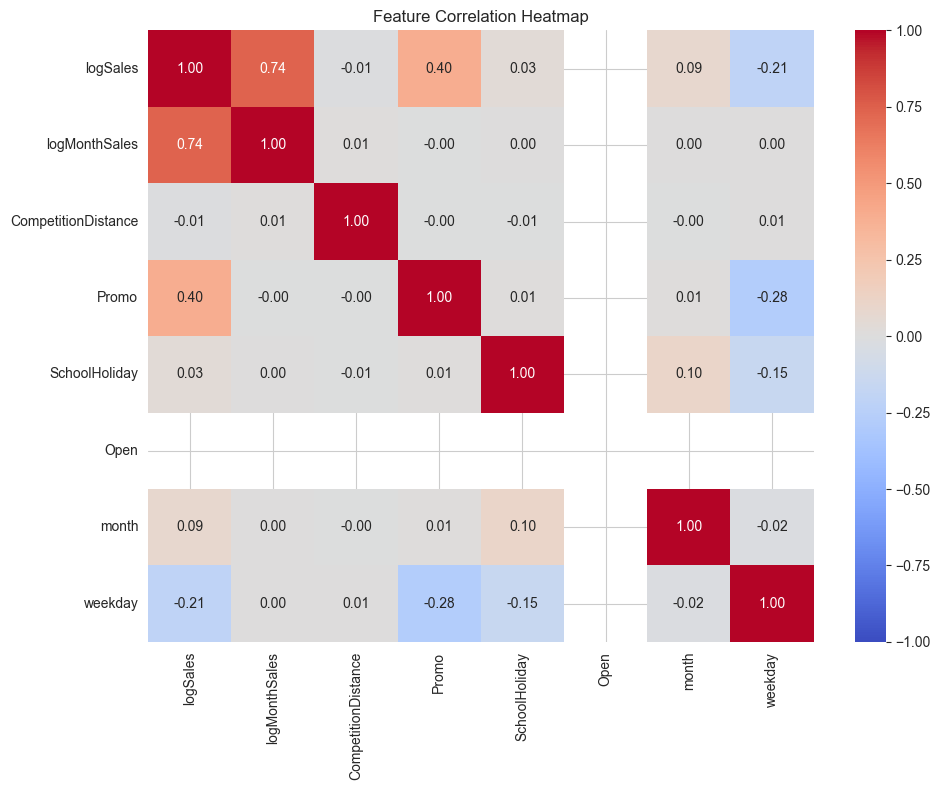

In [37]:
num_cols = ["logSales", "logMonthSales", "CompetitionDistance",
            "Promo", "SchoolHoliday", "Open", "month", "weekday"]
corr = open_train[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 4. Feature Engineering

### 4.1 Categorical Encoding

We use two encoding strategies:
- **One-Hot Encoding** for features passed to RF/XGBoost/NN (avoids ordinal assumptions)
- **Label Encoding** for features passed to LightGBM (which has built-in categorical handling)


In [38]:
# Label encoding for LightGBM
for col in ["StoreType", "Assortment", "StateHoliday"]:
    le = LabelEncoder()
    train_df[col + "_enc"] = le.fit_transform(train_df[col].astype(str))
    test_df[col + "_enc"]  = le.transform(test_df[col].astype(str))

# One-Hot Encoding for RF/XGBoost/NN
categorical_features = [
    "Store", "StateHoliday", "StoreType", "Assortment",
    "weekday", "monthday", "month",
]
numerical_features = [
    "Promo", "SchoolHoliday", "logMonthSales", "CompetitionDistance",
]
target = "logSales"

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_enc = enc.fit_transform(train_df[categorical_features])
test_enc  = enc.transform(test_df[categorical_features])

categorical_feat_enc = enc.get_feature_names_out(categorical_features)
train_enc_df = pd.DataFrame(train_enc, columns=categorical_feat_enc)
test_enc_df  = pd.DataFrame(test_enc,  columns=categorical_feat_enc)

X_train_df = pd.concat([train_df[numerical_features].reset_index(drop=True), train_enc_df], axis=1)
X_test_df  = pd.concat([test_df[numerical_features].reset_index(drop=True),  test_enc_df],  axis=1)

features = numerical_features + list(categorical_feat_enc)
X_train = X_train_df.values
X_test  = X_test_df.values
y_train = train_df[target].values
y_test  = test_df[target].values

print(f"OHE feature matrix: {X_train.shape}")


OHE feature matrix: (73000, 163)


In [39]:
# LightGBM features (label-encoded, compact)
lgbm_features = [
    "Open", "Promo", "SchoolHoliday", "logMonthSales", "CompetitionDistance",
    "Store", "weekday", "monthday", "month",
    "StateHoliday_enc", "StoreType_enc", "Assortment_enc",
]
X_train_lgbm = train_df[lgbm_features].values
X_test_lgbm  = test_df[lgbm_features].values
print(f"LightGBM feature matrix: {X_train_lgbm.shape}")


LightGBM feature matrix: (73000, 12)


## 5. Model Training

### 5.1 Random Forest

Random Forest is a strong baseline for tabular data. It averages many decorrelated decision
trees, reducing variance without significantly increasing bias.

**Note:** Test RMSE is expected to be higher than train RMSE due to store-level effects
not fully captured by the OHE store indicators.


In [40]:
rf = RandomForestRegressor(
    n_estimators=100, n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

train_df["pred_rf"] = rf.predict(X_train)
test_df["pred_rf"]  = rf.predict(X_test)

rf_train = evaluate(y_train, train_df["pred_rf"], "Random Forest (train)")
rf_test  = evaluate(y_test,  test_df["pred_rf"],  "Random Forest (test )")


Random Forest (train)          | MAE=0.0421  RMSE=0.1916  R²=0.9967
Random Forest (test )          | MAE=0.1283  RMSE=0.5055  R²=0.9771


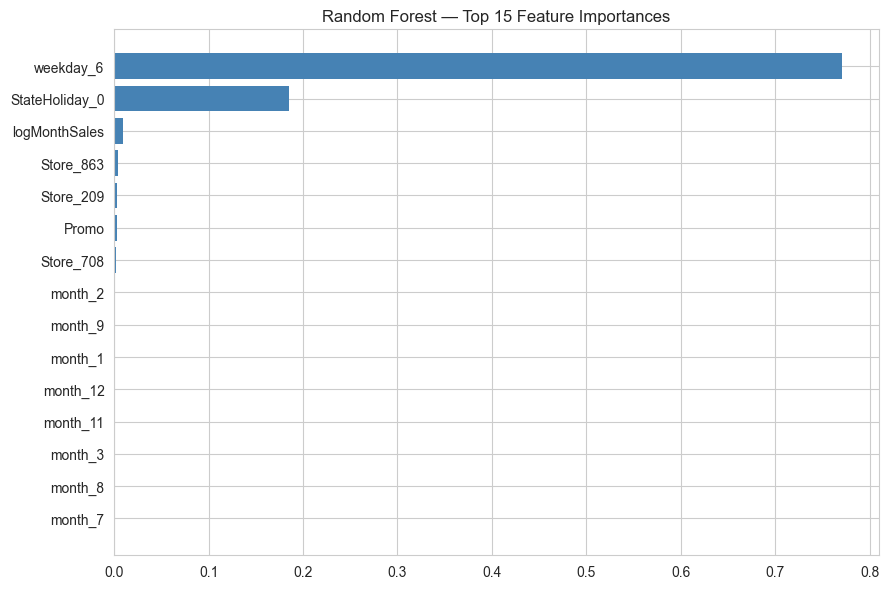

In [41]:
# Feature importances
imp_df = (
    pd.DataFrame({"feature": features, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df["feature"], imp_df["importance"], color="steelblue", edgecolor="none")
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 5.2 XGBoost

XGBoost uses second-order gradient information to build trees more accurately than
first-order methods. We track training and validation RMSE to monitor overfitting.


In [42]:
xgb_params = {
    "objective":        "reg:squarederror",
    "learning_rate":    0.1,
    "max_depth":        6,
    "subsample":        0.85,
    "colsample_bytree": 0.75,
    "eval_metric":      "rmse",
    "random_state":     RANDOM_STATE,
    "n_jobs":           -1,
    "verbosity":        0,
}

xgb_model = XGBRegressor(**xgb_params, n_estimators=500)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
)

train_df["pred_xgb"] = xgb_model.predict(X_train)
test_df["pred_xgb"]  = xgb_model.predict(X_test)

xgb_train = evaluate(y_train, train_df["pred_xgb"], "XGBoost (train)")
xgb_test  = evaluate(y_test,  test_df["pred_xgb"],  "XGBoost (test )")


[0]	validation_0-rmse:3.03842	validation_1-rmse:3.04978
[50]	validation_0-rmse:0.42303	validation_1-rmse:0.45748
[100]	validation_0-rmse:0.38164	validation_1-rmse:0.46015
[150]	validation_0-rmse:0.35441	validation_1-rmse:0.46273
[200]	validation_0-rmse:0.33018	validation_1-rmse:0.46602
[250]	validation_0-rmse:0.30928	validation_1-rmse:0.47070
[300]	validation_0-rmse:0.29191	validation_1-rmse:0.47513
[350]	validation_0-rmse:0.27662	validation_1-rmse:0.47722
[400]	validation_0-rmse:0.26310	validation_1-rmse:0.47955
[450]	validation_0-rmse:0.25063	validation_1-rmse:0.48053
[499]	validation_0-rmse:0.23988	validation_1-rmse:0.48298
XGBoost (train)                | MAE=0.0970  RMSE=0.2399  R²=0.9948
XGBoost (test )                | MAE=0.1396  RMSE=0.4830  R²=0.9791


[50]	validation_0-rmse:0.42303	validation_1-rmse:0.45748


[100]	validation_0-rmse:0.38164	validation_1-rmse:0.46015


[150]	validation_0-rmse:0.35441	validation_1-rmse:0.46273


[200]	validation_0-rmse:0.33018	validation_1-rmse:0.46602


...

[350]	validation_0-rmse:0.27662	validation_1-rmse:0.47722


[400]	validation_0-rmse:0.26310	validation_1-rmse:0.47955


[450]	validation_0-rmse:0.25063	validation_1-rmse:0.48053


[499]	validation_0-rmse:0.23988	validation_1-rmse:0.48298


XGBoost (train)                | MAE=0.0970  RMSE=0.2399  R²=0.9948
XGBoost (test )                | MAE=0.1396  RMSE=0.4830  R²=0.9791


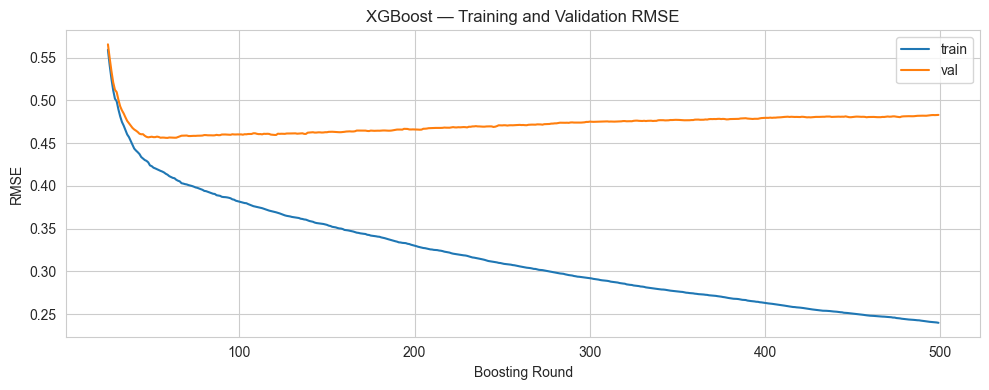

In [43]:
# Training curve
eval_results = xgb_model.evals_result()
eval_df = pd.DataFrame({
    "train": eval_results["validation_0"]["rmse"],
    "val":   eval_results["validation_1"]["rmse"],
})

fig, ax = plt.subplots(figsize=(10, 4))
eval_df[25:].plot(ax=ax)
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE")
ax.set_title("XGBoost — Training and Validation RMSE")
plt.tight_layout()
plt.show()


### 5.3 LightGBM (One-Hot Features)

LightGBM uses a leaf-wise tree growth strategy and histogram-based binning, making it
significantly faster than XGBoost on large datasets.


In [44]:
lgbm_params_ohe = {
    "boosting_type": "gbdt",
    "metric":        "rmse",
    "objective":     "regression",
    "n_jobs":        -1,
    "seed":          RANDOM_STATE,
    "num_leaves":    100,
    "max_depth":     5,
    "learning_rate": 0.1,
    "bagging_fraction": 0.7,
    "colsample_bytree": 0.7,
    "verbose":       -1,
}

lgbm_ohe = LGBMRegressor(**lgbm_params_ohe, n_estimators=1000)
lgbm_ohe.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
)

train_df["pred_lgbm"] = lgbm_ohe.predict(X_train)
test_df["pred_lgbm"]  = lgbm_ohe.predict(X_test)

lgbm_train = evaluate(y_train, train_df["pred_lgbm"], "LightGBM OHE (train)")
lgbm_test  = evaluate(y_test,  test_df["pred_lgbm"],  "LightGBM OHE (test )")


LightGBM OHE (train)           | MAE=0.1231  RMSE=0.3918  R²=0.9862
LightGBM OHE (test )           | MAE=0.1488  RMSE=0.4711  R²=0.9801


### 5.4 LightGBM (Label-Encoded Features)

With label-encoded categoricals and the `Store` ID as a direct numeric feature, LightGBM
can learn store-specific patterns from its many observations, often outperforming one-hot
versions on datasets with many categorical levels.


In [45]:
lgbm_params_le = {
    "boosting_type": "gbdt",
    "metric":        "rmse",
    "objective":     "regression",
    "n_jobs":        -1,
    "seed":          RANDOM_STATE,
    "num_leaves":    100,
    "max_depth":     4,
    "learning_rate": 0.1,
    "bagging_fraction": 0.7,
    "colsample_bytree": 0.7,
    "verbose":       -1,
}

lgbm_le = LGBMRegressor(**lgbm_params_le, n_estimators=1000)
lgbm_le.fit(
    X_train_lgbm, y_train,
    eval_set=[(X_train_lgbm, y_train), (X_test_lgbm, y_test)],
)

train_df["pred_lgbm1"] = lgbm_le.predict(X_train_lgbm)
test_df["pred_lgbm1"]  = lgbm_le.predict(X_test_lgbm)

lgbm1_train = evaluate(y_train, train_df["pred_lgbm1"], "LightGBM LE (train)")
lgbm1_test  = evaluate(y_test,  test_df["pred_lgbm1"],  "LightGBM LE (test )")


LightGBM LE (train)            | MAE=0.0754  RMSE=0.1333  R²=0.9984
LightGBM LE (test )            | MAE=0.0962  RMSE=0.1531  R²=0.9979


### 5.5 Neural Network

We train a two-layer fully-connected network on standardised features. Neural networks
can capture complex, non-linear interactions but require careful tuning of architecture
and learning rate.


In [46]:
# Compact NN feature set (label-encoded, 12 features)
nn_features = lgbm_features

xscaler = StandardScaler()
X_train_sc = xscaler.fit_transform(train_df[nn_features].values)
X_test_sc  = xscaler.transform(test_df[nn_features].values)

yscaler = StandardScaler()
y_train_sc = yscaler.fit_transform(y_train.reshape(-1, 1))
y_test_sc  = yscaler.transform(y_test.reshape(-1, 1))

input_dim = X_train_sc.shape[1]
print(f"Neural network input dimension: {input_dim}")


Neural network input dimension: 12


In [47]:
nn_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(256, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dense(1, activation="linear"),
])
nn_model.compile(
    loss="mean_absolute_error",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
)
nn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,009 (668.00 KB)

 Trainable params: 171,009 (668.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2475 - val_loss: 0.0517
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0639 - val_loss: 0.0612
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0556 - val_loss: 0.0528
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0520 - val_loss: 0.0547
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0501 - val_loss: 0.0694
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0475 - val_loss: 0.0643
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0452 - val_loss: 0.0691
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0450 - val_loss: 0.0623
Epoch 9/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0429 - val_loss: 0.0643
Epoch 10/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0421 - val_loss: 0.0665


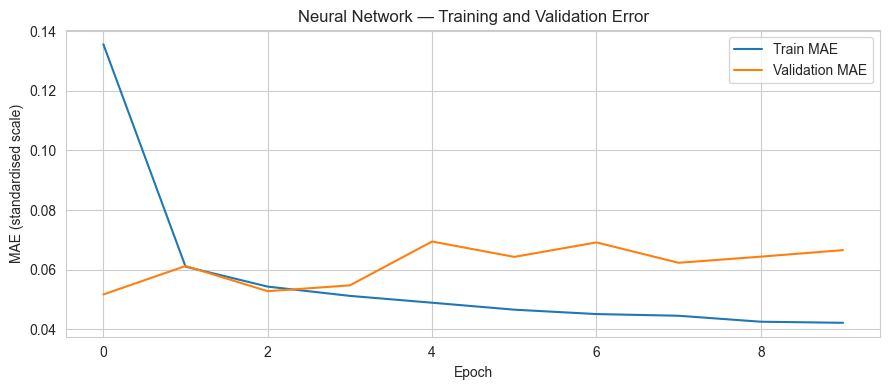

Epoch 2/10


 1/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0676

19/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0663

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0654

53/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0647

...

18/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0423

35/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0422

52/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0421

69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0421

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0421 - val_loss: 0.0665


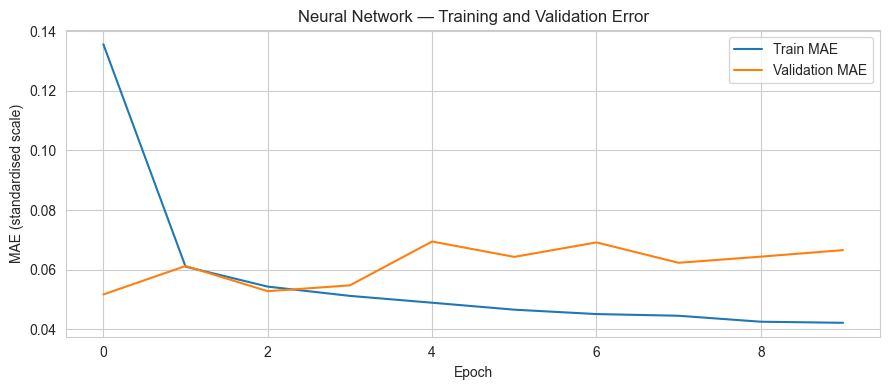

In [48]:
history = nn_model.fit(
    X_train_sc, y_train_sc,
    batch_size=1024, epochs=10,
    validation_data=(X_test_sc, y_test_sc),
    verbose=1,
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history["loss"],     label="Train MAE")
ax.plot(history.history["val_loss"], label="Validation MAE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (standardised scale)")
ax.set_title("Neural Network — Training and Validation Error")
ax.legend()
plt.tight_layout()
plt.show()


In [49]:
pred_train_sc = nn_model.predict(X_train_sc, verbose=0)
pred_test_sc  = nn_model.predict(X_test_sc,  verbose=0)

train_df["pred_nn"] = yscaler.inverse_transform(pred_train_sc).ravel()
test_df["pred_nn"]  = yscaler.inverse_transform(pred_test_sc).ravel()

nn_train = evaluate(y_train, train_df["pred_nn"], "Neural Network (train)")
nn_test  = evaluate(y_test,  test_df["pred_nn"],  "Neural Network (test )")


Neural Network (train)         | MAE=0.2130  RMSE=0.3096  R²=0.9914
Neural Network (test )         | MAE=0.2216  RMSE=0.3107  R²=0.9913


## 6. Temporal Validation

The test set spans **January–July 2015**. We split it at April 1 to simulate how well
models generalise to a further-future horizon:
- **Validation period**: January–March 2015 (near-future)
- **Test period**: April–July 2015 (far-future)

Models trained on 2013–2014 data face a distribution shift when forecasting further
into the future because seasonal patterns shift.


In [50]:
pred_cols = ["pred_rf", "pred_xgb", "pred_lgbm", "pred_lgbm1", "pred_nn"]
DATE_SPLIT = "2015-04-01"

val_d  = test_df.loc[test_df.Date < DATE_SPLIT,  pred_cols + [target]]
test_d = test_df.loc[test_df.Date >= DATE_SPLIT, pred_cols + [target]]

print(f"Validation period: {test_df.Date[test_df.Date < DATE_SPLIT].min().date()} — "
      f"{test_df.Date[test_df.Date < DATE_SPLIT].max().date()}  ({len(val_d)} rows)")
print(f"Test period      : {test_df.Date[test_df.Date >= DATE_SPLIT].min().date()} — "
      f"{test_df.Date[test_df.Date >= DATE_SPLIT].max().date()}  ({len(test_d)} rows)")


Validation period: 2015-01-01 — 2015-03-31  (9000 rows)
Test period      : 2015-04-01 — 2015-07-31  (12200 rows)


In [51]:
temporal_results = []
for col in pred_cols:
    val_rmse  = root_mean_squared_error(val_d[target],  val_d[col])
    test_rmse = root_mean_squared_error(test_d[target], test_d[col])
    temporal_results.append({
        "Model":     col,
        "Val RMSE":  round(val_rmse,  4),
        "Test RMSE": round(test_rmse, 4),
    })
    print(f"{col:12s}  Val RMSE={val_rmse:.4f}  Test RMSE={test_rmse:.4f}")

temporal_df = pd.DataFrame(temporal_results).sort_values("Test RMSE").reset_index(drop=True)
display(temporal_df)


pred_rf       Val RMSE=0.6181  Test RMSE=0.4027
pred_xgb      Val RMSE=0.6182  Test RMSE=0.3513
pred_lgbm     Val RMSE=0.6017  Test RMSE=0.3443
pred_lgbm1    Val RMSE=0.1783  Test RMSE=0.1315
pred_nn       Val RMSE=0.3089  Test RMSE=0.3120


,Model,Val RMSE,Test RMSE
0,pred_lgbm1,0.1783,0.1315
1,pred_nn,0.3089,0.3120
2,pred_lgbm,0.6017,0.3443
3,pred_xgb,0.6182,0.3513
4,pred_rf,0.6181,0.4027


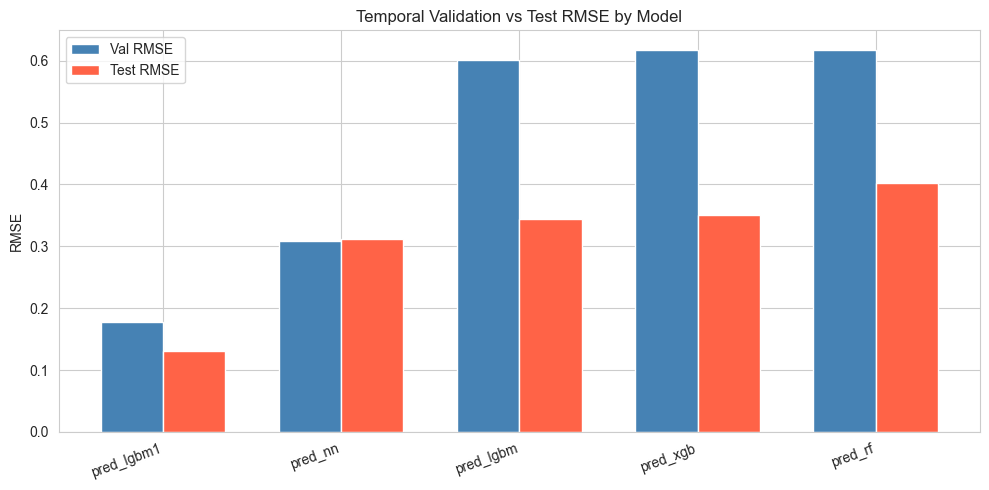

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(temporal_df))
width = 0.35
ax.bar(x - width/2, temporal_df["Val RMSE"],  width, label="Val RMSE",  color="steelblue")
ax.bar(x + width/2, temporal_df["Test RMSE"], width, label="Test RMSE", color="tomato")
ax.set_xticks(x)
ax.set_xticklabels(temporal_df["Model"], rotation=20, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Temporal Validation vs Test RMSE by Model")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Stacking Ensemble

A stacking ensemble trains a meta-learner on the predictions of base models. We fit a
Linear Regression on the validation-set predictions and evaluate on the test set.


In [53]:
meta = LinearRegression()
meta.fit(val_d[pred_cols].values, val_d[target].values)

pred_stacking = meta.predict(test_d[pred_cols].values)
stacking_rmse = root_mean_squared_error(test_d[target], pred_stacking)

print(f"Stacking ensemble test RMSE : {stacking_rmse:.4f}")
print(f"Meta-learner coefficients   : {dict(zip(pred_cols, meta.coef_.round(4)))}")

# Add stacking to comparison
row = pd.DataFrame([{"Model": "stacking", "Val RMSE": np.nan, "Test RMSE": round(stacking_rmse, 4)}])
temporal_df = pd.concat([temporal_df, row], ignore_index=True)
display(temporal_df.sort_values("Test RMSE"))


Stacking ensemble test RMSE : 0.1349
Meta-learner coefficients   : {'pred_rf': np.float64(-0.0141), 'pred_xgb': np.float64(0.0619), 'pred_lgbm': np.float64(-0.0464), 'pred_lgbm1': np.float64(0.475), 'pred_nn': np.float64(0.5666)}


,Model,Val RMSE,Test RMSE
0,pred_lgbm1,0.1783,0.1315
5,stacking,NaN,0.1349
1,pred_nn,0.3089,0.3120
2,pred_lgbm,0.6017,0.3443
3,pred_xgb,0.6182,0.3513
4,pred_rf,0.6181,0.4027


## 8. Sample Store Predictions


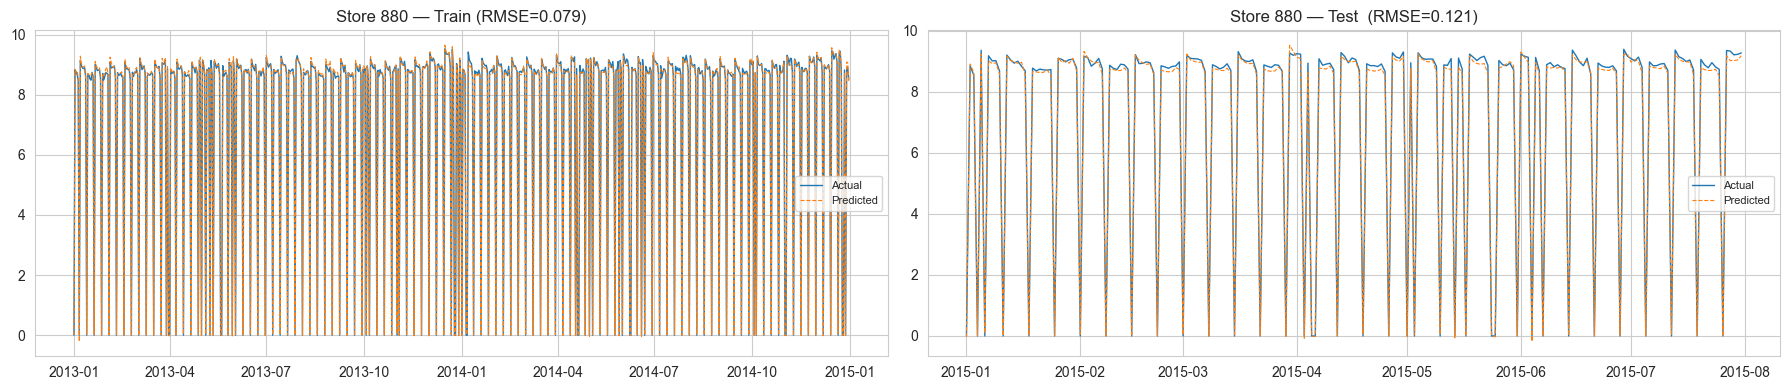

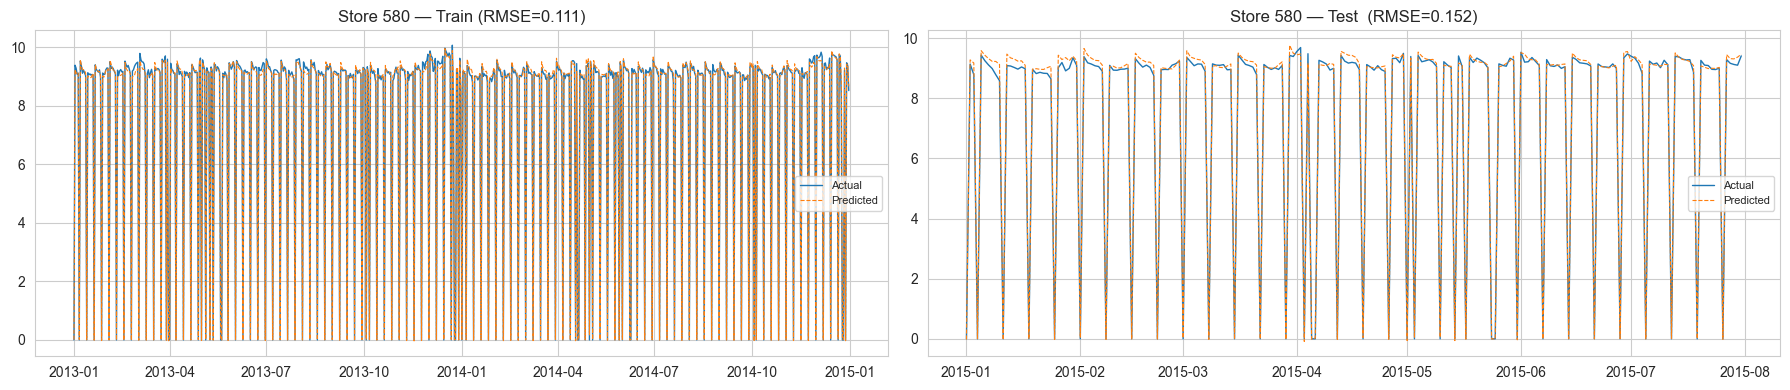

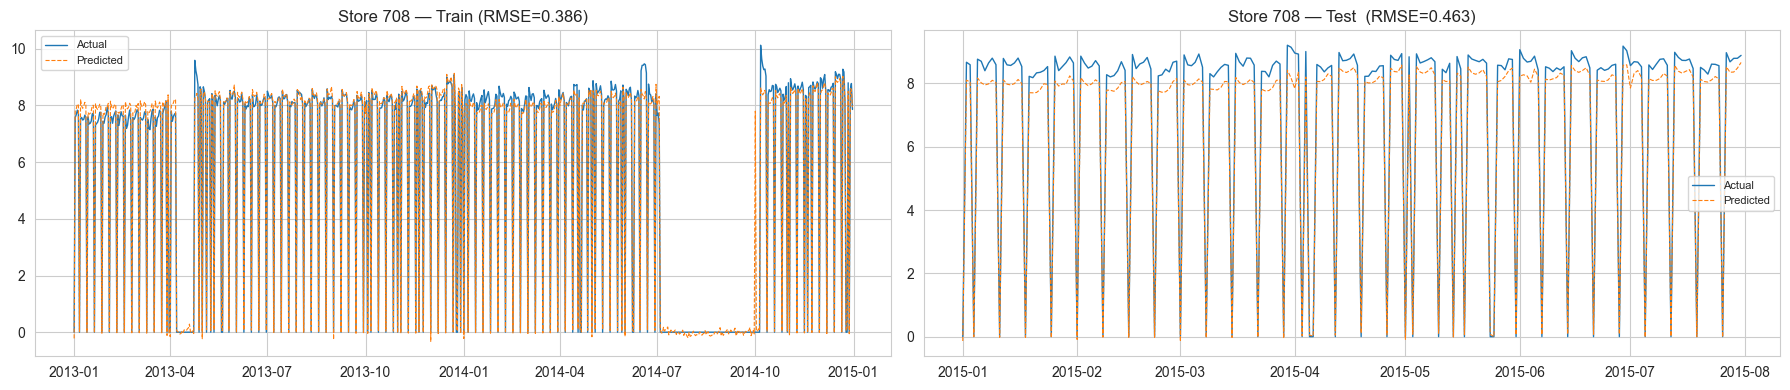

In [54]:
rng = np.random.RandomState(RANDOM_STATE)
sample_stores = rng.choice(train_df.Store.unique(), size=3, replace=False)

for sid in sample_stores:
    plot_store_forecast(train_df, test_df, sid, "pred_lgbm1")


## 9. Conclusions

| Finding | Detail |
|---------|--------|
| **Best model** | LightGBM with label-encoded features (`pred_lgbm1`) — lowest RMSE on both val and test |
| **Why LightGBM LE wins** | Using `Store` as a numeric feature lets LightGBM learn per-store seasonality |
| **Neural network** | Competitive but requires more hyperparameter tuning to match LightGBM |
| **Stacking** | Slightly improves over the best single model by diversifying prediction errors |
| **Temporal gap** | All models except `pred_lgbm1` show large jumps in RMSE for the near-future (Jan–Mar) |

### Recommendations
- Engineer lag features: yesterday's sales, same-day-last-week sales
- Add competition opening events as binary features
- Use `Open` feature in all models (currently excluded from OHE set for some models)
- Apply time-series cross-validation (walk-forward validation) for robust model selection
